In [2]:
import numpy as np

from qiskit_noise_model import *
from qiskit_trotter_circuit import *
import matplotlib.pyplot as plt

from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp, Operator

# Test

In [3]:
X = SparsePauliOp("X")
Y = SparsePauliOp("Y")
Z = SparsePauliOp("Z")
I = SparsePauliOp("I")
 
# build the evolution gate
operator = 0.5*(X ^ X) + 0.5*(Y ^ Y)
evo = PauliEvolutionGate(operator, time=0.2)

qc = QuantumCircuit(2)
qc.append(evo, range(2))
qc = transpile(qc, basis_gates=["rzz", "u"], optimization_level=3)

qc.draw()

c:\Users\Jielun\Documents\GitHub\one_hot_QTT\.venv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\Jielun\Documents\GitHub\one_hot_QTT\.venv\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


global phase: 3π/2
     ┌────────────┐          ┌───────────────┐          ┌──────────────────┐
q_0: ┤ U(π/2,0,π) ├─■────────┤ U(π/2,0,-π/2) ├─■────────┤ U(-π/2,-π/2,π/2) ├
     ├────────────┤ │ZZ(0.2) ├───────────────┤ │ZZ(0.2) ├──────────────────┤
q_1: ┤ U(π/2,0,π) ├─■────────┤ U(π/2,0,-π/2) ├─■────────┤ U(-π/2,-π/2,π/2) ├
     └────────────┘          └───────────────┘          └──────────────────┘

# Construct circuit

OrderedDict([('u', 363), ('rzz', 190), ('measure', 4)])
OrderedDict([('u', 508), ('rzz', 270), ('measure', 8)])


# Construct model noise

In [19]:
'''
# noisy simulator
pauli2q_probs = {
    # dominant dephasing
    "ZI": 0.22,
    "IZ": 0.22,
    "ZZ": 0.20,

    # single-qubit bit-flip–like errors
    "XI": 0.06,
    "IX": 0.06,
    "YI": 0.06,
    "IY": 0.06,

    # correlated transverse errors (small)
    "XX": 0.04,
    "YY": 0.04,

    # very small mixed terms
    "XZ": 0.01,
    "ZX": 0.01,
    "YZ": 0.01,
    "ZY": 0.01
}
# sums to 1.00


noise = make_noise_model(
    p2=9e-4,       # exaggerate so effect is visible
    pauli2q_probs=pauli2q_probs,
    p01=7e-4,
    p10=1.3e-3
)
'''

D = 1
n, logq = 2, 3
q = 2**logq
assert 2**(n*logq) == q**n

inv_prob = []

for n_steps in range(20):
    qc_binary = binary_gray_trotter_circuit(D, n*logq, 0, 0.01, n_steps)
    qc_one_hot = one_hot_gray_trotter_circuit(D, n, q, 0, 0.01, n_steps)
    #qc_one_hot.draw()

    basis = ["rzz", "u"]
    qc_binary = transpile(qc_binary, basis_gates=basis, optimization_level=3)
    print(qc_binary.count_ops())
    qc_one_hot = transpile(qc_one_hot, basis_gates=basis, optimization_level=3)
    print(qc_one_hot.count_ops())

    noise = quantinuum_params_to_aer_noise_model()

    ideal_sim = AerSimulator()
    noisy_sim = AerSimulator(noise_model=noise)

    ideal_binary = normalize(run_counts(qc_binary, ideal_sim))
    noisy_binary = normalize(run_counts(qc_binary, noisy_sim))

    print("TVD =", tvd(ideal_binary, noisy_binary))

    ideal_one_hot = normalize(run_counts(qc_one_hot, ideal_sim))
    counts, proj_counts, prob = run_counts(qc_one_hot, noisy_sim, one_hot_params=(D, n, q))
    noisy_one_hot = normalize(counts)
    proj_noisy_one_hot = normalize(proj_counts)

    inv_prob.append(1/prob)

    print("TVD =", tvd(ideal_one_hot, noisy_one_hot))
    print("Projected TVD =", tvd(ideal_one_hot, proj_noisy_one_hot))

OrderedDict([('measure', 6), ('u', 2)])
OrderedDict([('measure', 16), ('u', 2)])
TVD = 0.004600000000000023
Success probability: 0.9882
TVD = 0.011800000000000015
Projected TVD = 0.0
OrderedDict([('u', 149), ('rzz', 74), ('measure', 6)])
OrderedDict([('u', 130), ('rzz', 63), ('measure', 16)])
TVD = 0.05420000000000002
Success probability: 0.951
TVD = 0.053000000000000026
Projected TVD = 0.004226708727655141
OrderedDict([('u', 291), ('rzz', 148), ('measure', 6)])
OrderedDict([('u', 244), ('rzz', 126), ('measure', 16)])
TVD = 0.08239999999999997
Success probability: 0.9152
TVD = 0.09399999999999997
Projected TVD = 0.010070979020979054
OrderedDict([('u', 433), ('rzz', 222), ('measure', 6)])
OrderedDict([('u', 358), ('rzz', 189), ('measure', 16)])
TVD = 0.11500000000000002
Success probability: 0.885
TVD = 0.12580000000000002
Projected TVD = 0.01248926553672315
OrderedDict([('u', 575), ('rzz', 296), ('measure', 6)])
OrderedDict([('u', 472), ('rzz', 252), ('measure', 16)])
TVD = 0.1460000000

1.8910741301059

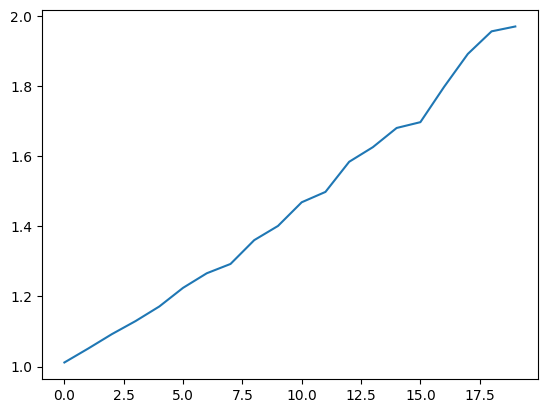

In [22]:
plt.plot(inv_prob)

In [8]:
#ideal_binary, ideal_one_hot